# SVM Exercises

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import metrics

Load Pima diabetes dataset

In [3]:
url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/diabetes.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

# YOUR CODE HERE
data = pd.read_csv(url,names=names)

invalid = ['plas', 'pres', 'skin', 'test', 'mass']

for i in invalid:
  data[i].replace(to_replace=0, value=np.nan, inplace=True)

data = data.dropna(axis=0).reset_index(drop=True)

data.head()

/tmp/ipykernel_3713/541147881.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].replace(to_replace=0, value=np.nan, inplace=True)


,preg,plas,pres,skin,test,mass,pedi,age,class
0,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
1,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
2,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
3,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
4,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


Split data into training, colidation, and test sets with a test size of 25%

In [12]:
# YOUR CODE HERE
X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
y_col = 'class'

test_size = 0.25
X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size=test_size, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=0)

Create a model with sklearn's SVC and a high gamma value (perhaps 1.0)

In [13]:
# YOUR CODE HERE
svm1 = SVC(gamma=1, C=1)
svm1.fit(X_train, y_train)


SVC(C=1, gamma=1)

Print accuracy of training and validation data

In [14]:
# YOUR CODE HERE
y_train_pred=svm1.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=svm1.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  100.0
Validation Accuracy is  67.56756756756756


Create a model with sklearn's SVC and a low gamma value (perhaps .001)

In [15]:
# YOUR CODE HERE
svm = SVC(gamma=0.001, C=1)
svm.fit(X_train, y_train)

SVC(C=1, gamma=0.001)

Print accuracy of training and validation data

In [16]:
# YOUR CODE HERE
y_train_pred = svm.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=svm.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val, y_val_pred)*100)

Training Accuracy is  87.27272727272727
Validation Accuracy is  74.32432432432432


Explain the accuracy results below.

The training accuracy is 100% in both and the validation score is only 67.567% in both, this suggests that there can be a over-fit in this model.

Print the confusion matrices for your high and low gamma models (both numeric and visualized)

In [25]:
# YOUR CODE HERE

y_val_predict_highgamma = svm1.predict(X_val)
y_val_predict_lowgamma = svm.predict(X_val)

print("Confustion Matrix of High Gamme:")
labels = [0,1]
cm = metrics.confusion_matrix(y_val, y_val_predict_highgamma, labels=labels)
print(cm)

print("\n Normalized Confusion Matrix of High Gamma: ")
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
print(cm_norm)

print("Confustion Matrix of Low Gamme:")
labels = [0,1]
cm1 = metrics.confusion_matrix(y_val, y_val_predict_lowgamma, labels=labels)
print(cm1)

print("\n Normalized Confusion Matrix of Low Gamma: ")
cm1_norm = cm1.astype(float) / cm1.sum(axis=1)[:, np.newaxis]
print(cm1_norm)

Confustion Matrix of High Gamme:
[[50  0]
 [24  0]]

 Normalized Confusion Matrix of High Gamma: 
[[1. 0.]
 [1. 0.]]
Confustion Matrix of Low Gamme:
[[48  2]
 [17  7]]

 Normalized Confusion Matrix of Low Gamma: 
[[0.96       0.04      ]
 [0.70833333 0.29166667]]


In [30]:
print("Confustion Matrix of High Gamme:")
pd.crosstab(y_val, y_val_predict_highgamma, rownames=['True'], colnames=['Predicted'], margins=True)

Confustion Matrix of High Gamme:


Predicted,0,All
True,,
0,50,50
1,24,24
All,74,74


In [31]:
print("Confustion Matrix of Low Gamme:")
pd.crosstab(y_val, y_val_predict_lowgamma, rownames=['True'], colnames=['Predicted'], margins=True)

Confustion Matrix of Low Gamme:


Predicted,0,1,All
True,,,
0,48,2,50
1,17,7,24
All,65,9,74


/tmp/ipykernel_3713/1171551611.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels, fontsize=16)
/tmp/ipykernel_3713/1171551611.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels, fontsize=16)


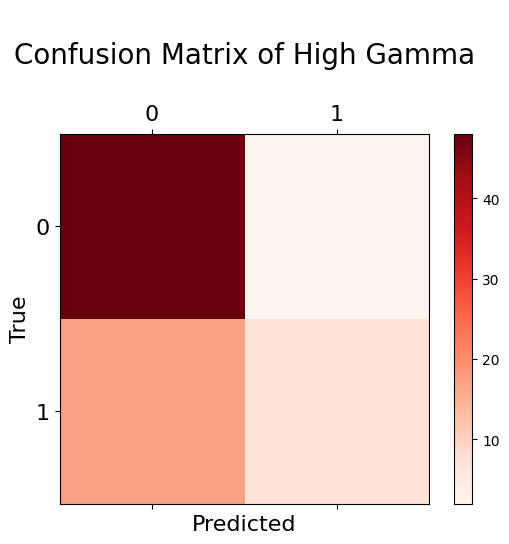

/tmp/ipykernel_3713/1171551611.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels, fontsize=16)
/tmp/ipykernel_3713/1171551611.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels, fontsize=16)


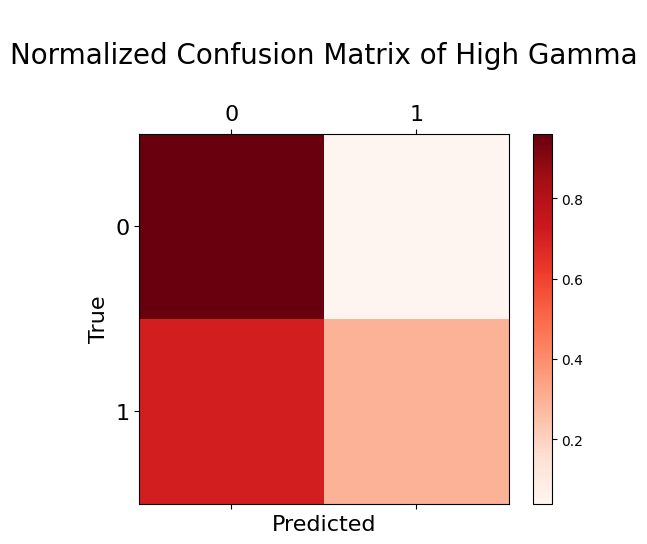

/tmp/ipykernel_3713/1171551611.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels, fontsize=16)
/tmp/ipykernel_3713/1171551611.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels, fontsize=16)


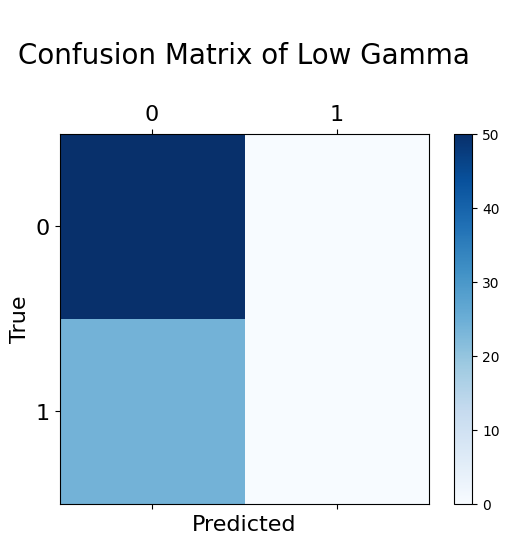

/tmp/ipykernel_3713/1171551611.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels, fontsize=16)
/tmp/ipykernel_3713/1171551611.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels, fontsize=16)


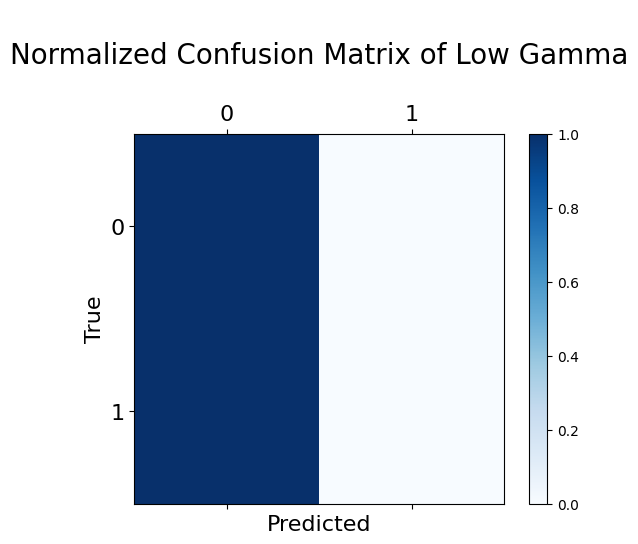

In [34]:
def plot_cmatrix(cm,labels,title='Confusion Matrix of High Gamma'):
  fig = plt.figure()
  ax = fig.add_subplot(111)
  cax = ax.matshow(cm,cmap='Reds')
  plt.title('\n'+title+'\n', fontsize=20)
  fig.colorbar(cax)
  ax.set_xticklabels([''] + labels, fontsize=16)
  ax.set_yticklabels([''] + labels, fontsize=16)
  plt.xlabel('Predicted', fontsize=16)
  plt.ylabel('True', fontsize=16)
  plt.show()

plot_cmatrix(cm1,labels=labels)
plot_cmatrix(cm1_norm,labels,title='Normalized Confusion Matrix of High Gamma')


def plot_cmatrix(cm,labels,title='Confusion Matrix of Low Gamma'):
  fig = plt.figure()
  ax = fig.add_subplot(111)
  cax = ax.matshow(cm,cmap='Blues')
  plt.title('\n'+title+'\n', fontsize=20)
  fig.colorbar(cax)
  ax.set_xticklabels([''] + labels, fontsize=16)
  ax.set_yticklabels([''] + labels, fontsize=16)
  plt.xlabel('Predicted', fontsize=16)
  plt.ylabel('True', fontsize=16)
  plt.show()

plot_cmatrix(cm,labels=labels)
plot_cmatrix(cm_norm,labels,title='Normalized Confusion Matrix of Low Gamma')